In [11]:
import matplotlib.pyplot as plt

import sys
from os.path import dirname, abspath, join
sys.path.append('G:/Codes/LuttingerWard_from_ML/code/models')
from model_FC import FC_01
from model_AE_FC import AE_FC_01
from model_AE_FC_transfer import AE_FC_02
sys.path.append('G:/Codes/LuttingerWard_from_ML/code/models/IO')
from DataMod_FC import *
sys.path.append('G:/Codes/LuttingerWard_from_ML/code/models/utils')
from Callbacks import TestLogger


import pytorch_lightning as L
import torch
from pytorch_lightning.loggers import TensorBoardLogger, NeptuneLogger, CSVLogger
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor, EarlyStopping, StochasticWeightAveraging, GradientAccumulationScheduler,  DeviceStatsMonitor

from argparse import ArgumentParser
torch.set_float32_matmul_precision("high")
torch.set_default_dtype(torch.float64)
import json
import os, copy, gc
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt


In [9]:
dir_name = 'G:/Codes/LuttingerWard_from_ML/.neptune/AE_FC_FCDimScale_with_dens'

df = pd.DataFrame(columns=['Layers', 'FC_dim', 'Epoch', 'Loss', 'model_number', 'path'])
subfolders = [ f.path for f in os.scandir(dir_name) if f.is_dir() ]
checkpoints = []
checkpoints_paths = []
hparams_list = []
models_list = []
nparams_list = []
for i,dir in enumerate(subfolders):
    ckp_path = os.path.join(os.path.join(dir_name,dir), 'checkpoints/last.ckpt') 
    checkpoint = torch.load(ckp_path, weights_only=False)
    checkpoints.append(checkpoint)
    checkpoints_paths.append(ckp_path)
    print(ckp_path)
    
    with open("../configs/confmod_AE_FC_transfer_with_dens.json") as f:
        json1_data = json.loads(f.read())
    hparams = checkpoint['hyper_parameters']
    for k in hparams:
        json1_data[k] = hparams[k]
    
    hparams_list.append(json1_data)
    #for k in checkpoint['hyper_parameters']:
    #    print(k, ": ",  json1_data[k])
    NLayers = checkpoint['hyper_parameters']["latent_layers"]

    kk = list(checkpoint["callbacks"].keys())[2]
    train_score = checkpoint["callbacks"][kk]['best_model_score'].item()
    kk2 = list(checkpoint['callbacks'].keys())[2]
    model_path = checkpoint['callbacks'][kk2]['best_model_path']
    ind0 = model_path.find("LWAEP")
    model_number = int(model_path[ind0+6:ind0+9])
    json1_data["FC_layers"] = NLayers
    model = AE_FC_02.load_from_checkpoint(ckp_path, config=json1_data, weights_only=False)
    model_nparams = sum(p.numel() for p in model.parameters())
    models_list.append(model)
    nparams_list.append(model_nparams)
    df.loc[i] = [NLayers, checkpoint['hyper_parameters']["FC_dim"], checkpoint["epoch"], train_score, model_number, ckp_path]
df["nparams"] = df["FC_dim"] * df["Layers"]
df["log_loss"] = np.log10(df["Loss"])

G:/Codes/LuttingerWard_from_ML/.neptune/AE_FC_FCDimScale_with_dens\LWAEP-204\checkpoints/last.ckpt


g:\miniconda3\envs\myenv\Lib\site-packages\lightning_fabric\utilities\cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


G:/Codes/LuttingerWard_from_ML/.neptune/AE_FC_FCDimScale_with_dens\LWAEP-205\checkpoints/last.ckpt


g:\miniconda3\envs\myenv\Lib\site-packages\lightning_fabric\utilities\cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


G:/Codes/LuttingerWard_from_ML/.neptune/AE_FC_FCDimScale_with_dens\LWAEP-206\checkpoints/last.ckpt


...

g:\miniconda3\envs\myenv\Lib\site-packages\lightning_fabric\utilities\cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


G:/Codes/LuttingerWard_from_ML/.neptune/AE_FC_FCDimScale_with_dens\LWAEP-273\checkpoints/last.ckpt


g:\miniconda3\envs\myenv\Lib\site-packages\lightning_fabric\utilities\cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


G:/Codes/LuttingerWard_from_ML/.neptune/AE_FC_FCDimScale_with_dens\LWAEP-275\checkpoints/last.ckpt


g:\miniconda3\envs\myenv\Lib\site-packages\lightning_fabric\utilities\cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


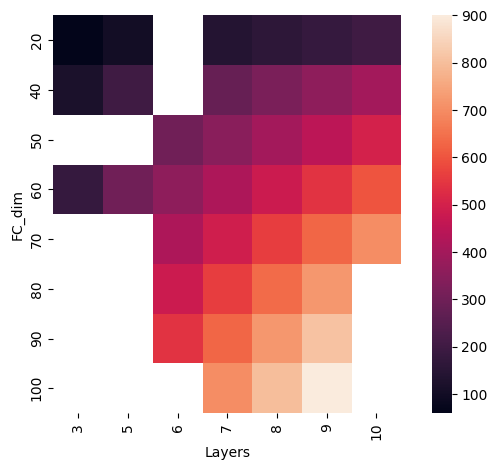

In [12]:

piv = pd.pivot_table(df, values="nparams",columns=["Layers"], index=["FC_dim"], fill_value=np.nan)

ax = sns.heatmap(piv, square=True)
plt.setp( ax.xaxis.get_majorticklabels(), rotation=90 )
plt.tight_layout()
plt.show()

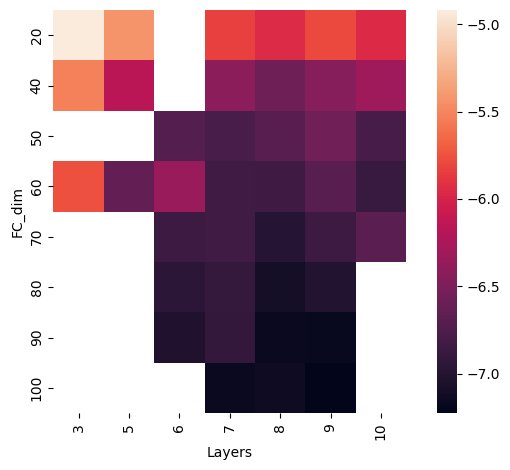

In [ ]:

piv = pd.pivot_table(df, values="log_loss",columns=["Layers"], index=["FC_dim"], fill_value=np.nan)
ax = sns.heatmap(piv, square=True)
plt.setp( ax.xaxis.get_majorticklabels(), rotation=90 )
plt.tight_layout()
plt.show()

In [ ]:
device = "cuda"
device_loc = "cpu"
FC_dims = []
FC_nums = []
model_loss = []
model_loss_NB3 = []
model_loss_NB4 = []
nparams2 = []
bs = 2**17

loss_i = -1
loss_i_NB3 = -1
loss_i_NB4 = -1
device = "cpu"
test_set_paths = [["D:/NB2_f64_xdata.pt", "D:/NB2_f64_ydata.pt", 8320209],
                  ["D:/NB3_f64_xdata.pt", "D:/NB3_f64_ydata.pt", 9150901],
                  ["D:/NB4_f64_xdata.pt", "D:/NB4_f64_ydata.pt", 9510750]]
lossf = torch.nn.MSELoss()
for ii, test_path in enumerate(test_set_paths):
    tmp_hparams = copy.deepcopy(hparams_list[0])
    tmp_hparams["test_batch_size"] = bs
    tmp_hparams["batch_size"] = bs
    tmp_hparams["num_workers"] = 0
    tmp_hparams["persistent_workers"] = False
    with torch.no_grad():
        xdata = torch.from_file(test_path[0], size=test_path[2]*202).reshape(test_path[2],202)
        ndens, beta, GF_in = torch.split(xdata, [1,1,xdata.size(1)-2], dim=1) 
        ydata = torch.from_file(test_path[1], size=test_path[2]*200).reshape(test_path[2],200)
        bn = test_path[2] // bs + 1
        for model_i in range(len(models_list)):

            model = models_list[model_i]
            model.to(device)
            model.eval()
            loss_i = 0.0
            for bi in range(bn):
                tti = lossf(model(GF_in[bi*bs:(bi+1)*bs,:], ndens[bi*bs:(bi+1)*bs,:]),ydata[bi*bs:(bi+1)*bs,:])
                loss_i += tti*xdata[bi*bs:(bi+1)*bs,:].shape[0]
            loss_i = loss_i/test_path[2]
            print(f"{ii}[{bn}]: loss = {loss_i} ")

            if ii == 0:
                model_loss.append(loss_i)
            if ii == 1:
                loss_i_NB3 = loss_i
                model_loss_NB3.append(loss_i_NB3)
            if ii == 2:
                loss_i_NB4 = loss_i
                model_loss_NB4.append(loss_i_NB4)
 
            del model
            gc.collect()
        del xdata
        del ydata
        gc.collect()
model_loss = np.array(model_loss) 
model_loss_NB3 = np.array(model_loss_NB3) 
model_loss_NB4 = np.array(model_loss_NB4)


1.6855288932908954e-05 over 64
7.0191521741060435e-06 over 64
7.853002745462102e-06 over 64
9.350721077093851e-06 over 64
5.496764164575985e-06 over 64
3.553920657886661e-06 over 64
5.071172802121407e-06 over 64
2.1852170939370504e-06 over 64
3.8660151274225486e-06 over 64
3.853780527628338e-06 over 64
2.2730962630462336e-06 over 64
2.977658003273815e-06 over 64
3.0031162723740695e-06 over 64
3.826947720870813e-06 over 64
3.829896730464472e-06 over 64
3.6830258531739304e-06 over 64
4.641267462466027e-06 over 64
3.638694391529171e-06 over 64
5.808756824334465e-06 over 64
3.7377117200327573e-06 over 64
2.8771943554218784e-06 over 64
4.05964021296376e-06 over 64
2.8787931527670057e-06 over 64
2.39082224314764e-06 over 64
4.3801017726943416e-06 over 64
3.835200029601647e-06 over 64
2.5314011055497452e-06 over 64
3.199519711168142e-06 over 64
4.600435835467643e-06 over 64
3.1991361339083184e-06 over 64
3.840857840372587e-06 over 64
3.7470684268531563e-06 over 64
2.6293897731848186e-06 over 

In [120]:
df["test_loss_NB2"] = model_loss
df["test_loss_NB3"] = model_loss_NB3
df["test_loss_NB4"] = model_loss_NB4

In [122]:
df["test_logloss_NB2"] = np.log10(model_loss)
df["test_logloss_NB3"] = np.log10(model_loss_NB3)
df["test_logloss_NB4"] = np.log10(model_loss_NB4)

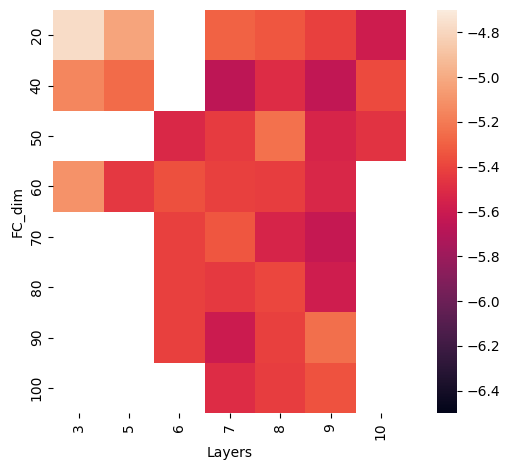

In [127]:
piv = pd.pivot_table(df, values="test_logloss_NB2",columns=["Layers"], index=["FC_dim"], fill_value=np.nan)
#plot pivot table as heatmap using seaborn
ax = sns.heatmap(piv, square=True, vmin=-6.5, vmax=-4.7)
plt.setp( ax.xaxis.get_majorticklabels(), rotation=90 )
plt.tight_layout()
plt.show()

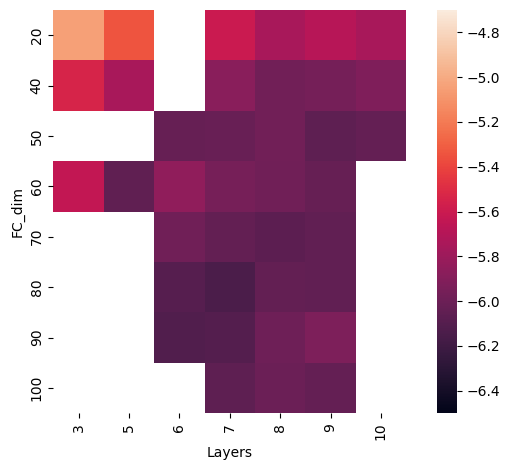

In [128]:
piv = pd.pivot_table(df, values="test_logloss_NB3",columns=["Layers"], index=["FC_dim"], fill_value=np.nan)
#plot pivot table as heatmap using seaborn
ax = sns.heatmap(piv, square=True, vmin=-6.5, vmax=-4.7)
plt.setp( ax.xaxis.get_majorticklabels(), rotation=90 )
plt.tight_layout()
plt.show()

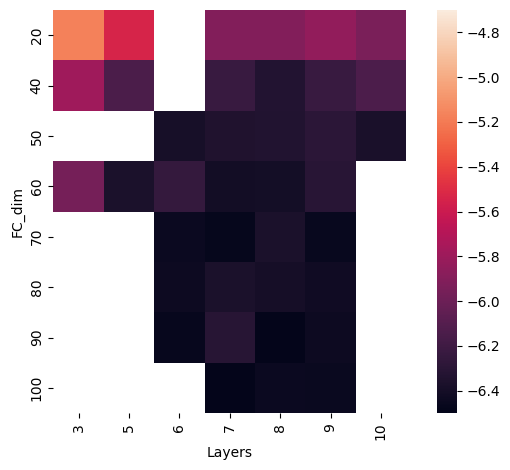

In [129]:
piv = pd.pivot_table(df, values="test_logloss_NB4",columns=["Layers"], index=["FC_dim"], fill_value=np.nan)
#plot pivot table as heatmap using seaborn
ax = sns.heatmap(piv, square=True, vmin=-6.5, vmax=-4.7)
plt.setp( ax.xaxis.get_majorticklabels(), rotation=90 )
plt.tight_layout()
plt.show()

In [6]:
eff_res_nparams = res_nparams - 2*5800

plt.rcParams.update({'font.size': 16})
#plt.imshow(u_nums, u_dims, res)
cbarlabel = "#Params"
fig, ax = plt.subplots()
im = ax.imshow(eff_res_nparams)
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel(cbarlabel, rotation=-90, va="bottom")
cbar.formatter.set_scientific(True)
cbar.formatter.set_powerlimits((0,0))
# Show all ticks and label them with the respective list entries
ax.set_xticks(np.arange(len(u_nums)), labels=u_nums)
ax.set_yticks(np.arange(len(u_dims)), labels=u_dims)


# Rotate the tick labels and set their alignment.
plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
         rotation_mode="anchor")

ax.set_xlabel("#FC Layers")
ax.set_ylabel("FC Dimension")

# Loop over data dimensions and create text annotations.
#for i in range(len(u_nums)):
#    for j in range(len(u_dims)):
#        text = ax.text(j, i, res[i, j],
#                       ha="center", va="center", color="w")

fig.tight_layout()
plt.savefig("NParams_cmp_AEFC.pdf")
plt.show()

NameError: name 'res_nparams' is not defined

C:\Users\Atomt\AppData\Local\Temp\ipykernel_8104\1419570737.py:5: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = ax.imshow(np.log10(res))
C:\Users\Atomt\AppData\Local\Temp\ipykernel_8104\1419570737.py:5: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = ax.imshow(np.log10(res))


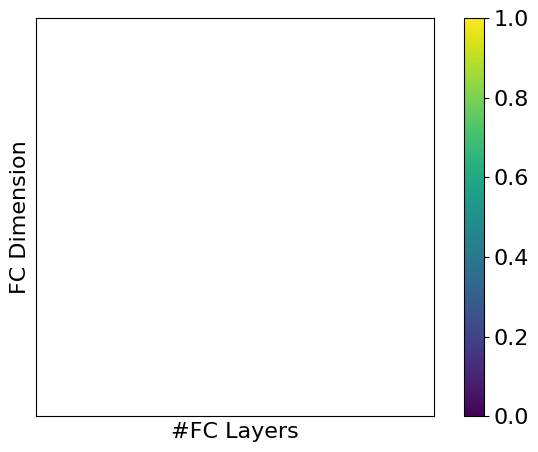

In [10]:
plt.rcParams.update({'font.size': 16})
#plt.imshow(u_nums, u_dims, res)
cbarlabel = "Log10(Loss)"
fig, ax = plt.subplots()
im = ax.imshow(np.log10(res))
cbar = ax.figure.colorbar(im, ax=ax)
#cbar.ax.set_ylabel(cbarlabel, rotation=-90, va="bottom")

# Show all ticks and label them with the respective list entries
ax.set_xticks(np.arange(len(u_nums)), labels=u_nums)
ax.set_yticks(np.arange(len(u_dims)), labels=u_dims)

# Rotate the tick labels and set their alignment.
plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
         rotation_mode="anchor")

ax.set_xlabel("#FC Layers")
ax.set_ylabel("FC Dimension")

# Loop over data dimensions and create text annotations.
#for i in range(len(u_nums)):
#    for j in range(len(u_dims)):
#        text = ax.text(j, i, res[i, j],
#                       ha="center", va="center", color="w")

fig.tight_layout()
plt.savefig("Loss_cmp_AEFC.pdf")
plt.show()

In [12]:
resNB3

array([], shape=(0, 0), dtype=float64)

C:\Users\Atomt\AppData\Local\Temp\ipykernel_8104\3467450451.py:5: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = ax.imshow(np.log10(resNB3))
C:\Users\Atomt\AppData\Local\Temp\ipykernel_8104\3467450451.py:5: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = ax.imshow(np.log10(resNB3))


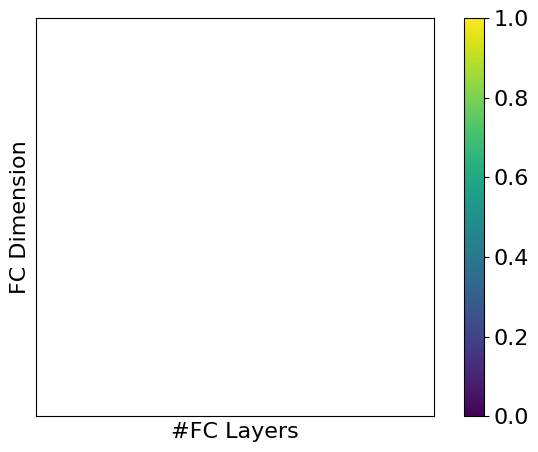

In [11]:
plt.rcParams.update({'font.size': 16})
#plt.imshow(u_nums, u_dims, res)
cbarlabel = "Log10(Loss)"
fig, ax = plt.subplots()
im = ax.imshow(np.log10(resNB3))
cbar = ax.figure.colorbar(im, ax=ax)
#cbar.ax.set_ylabel(cbarlabel, rotation=-90, va="bottom")

# Show all ticks and label them with the respective list entries
ax.set_xticks(np.arange(len(u_nums)), labels=u_nums)
ax.set_yticks(np.arange(len(u_dims)), labels=u_dims)

# Rotate the tick labels and set their alignment.
plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
         rotation_mode="anchor")

ax.set_xlabel("#FC Layers")
ax.set_ylabel("FC Dimension")

# Loop over data dimensions and create text annotations.
#for i in range(len(u_nums)):
#    for j in range(len(u_dims)):
#        text = ax.text(j, i, res[i, j],
#                       ha="center", va="center", color="w")

fig.tight_layout()
plt.savefig("Loss_cmp_AEFC_NB3.pdf")
plt.show()

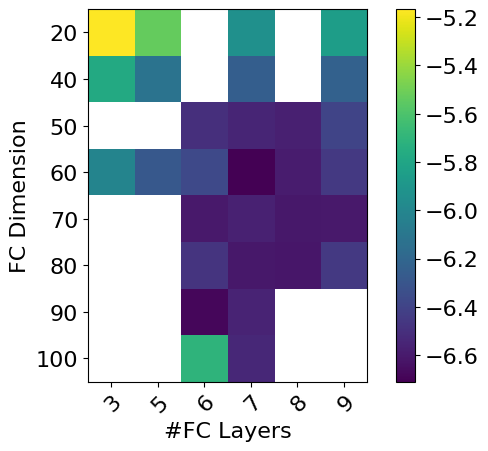

In [23]:
plt.rcParams.update({'font.size': 16})
#plt.imshow(u_nums, u_dims, res)
cbarlabel = "Log10(Loss)"
fig, ax = plt.subplots()
im = ax.imshow(np.log10(resNB4))
cbar = ax.figure.colorbar(im, ax=ax)
#cbar.ax.set_ylabel(cbarlabel, rotation=-90, va="bottom")

# Show all ticks and label them with the respective list entries
ax.set_xticks(np.arange(len(u_nums)), labels=u_nums)
ax.set_yticks(np.arange(len(u_dims)), labels=u_dims)

# Rotate the tick labels and set their alignment.
plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
         rotation_mode="anchor")

ax.set_xlabel("#FC Layers")
ax.set_ylabel("FC Dimension")

# Loop over data dimensions and create text annotations.
#for i in range(len(u_nums)):
#    for j in range(len(u_dims)):
#        text = ax.text(j, i, res[i, j],
#                       ha="center", va="center", color="w")

fig.tight_layout()
plt.savefig("Loss_cmp_AEFC_NB4.pdf")
plt.show()

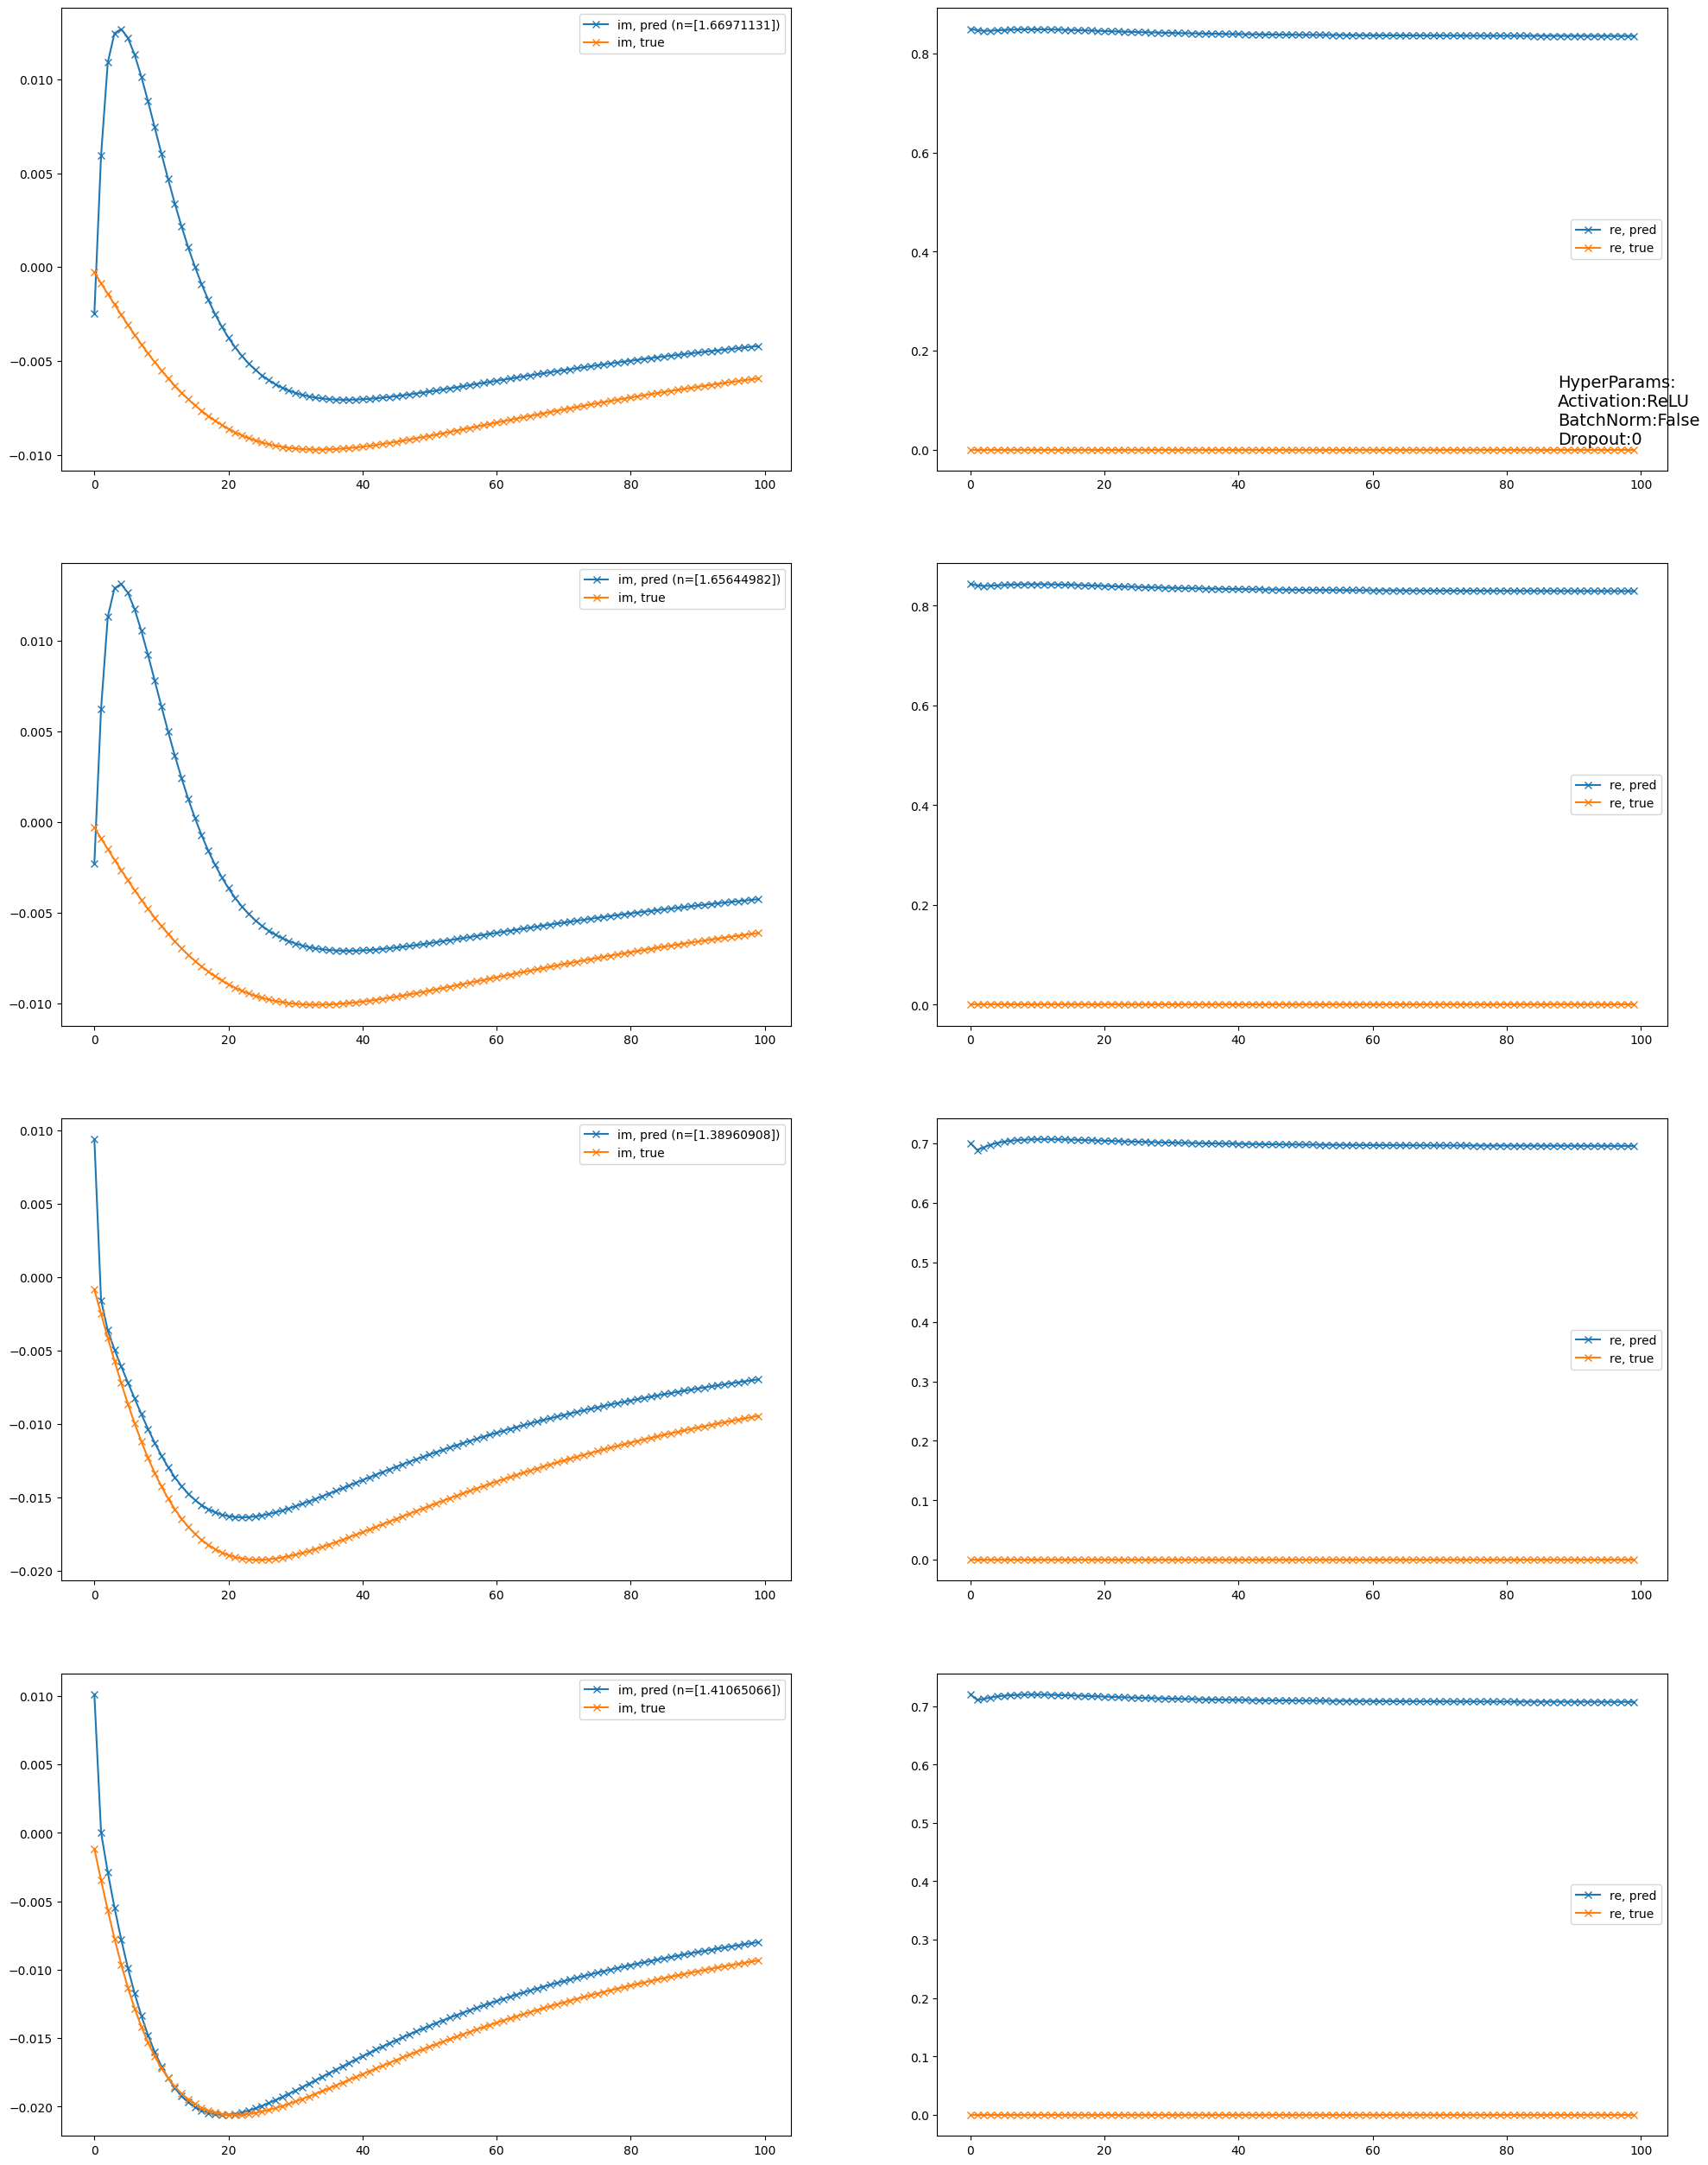

In [5]:
ind_list = [-1, -2,-1506,-1510]#,-1511,-1514,-1515, -1517, -1521]
fig,ax = plt.subplots(len(ind_list),2, figsize=(24,8*len(ind_list)))
x_test, SE_in = dataMod.test_dataset[ind_list]
ndens, beta, GF_in = torch.split(x_test, [1,1,x_test.size(1)-2], dim=1) 

x_test = x_test.to(device)
SE_hat = model(GF_in, ndens)

for i,ind in enumerate(ind_list):
    if i == 0:
        text = "HyperParams:\nActivation:{}\nBatchNorm:{}\nDropout:{}".format(model.hparams["activation"],model.hparams["with_batchnorm"],model.hparams["dropout"])
        ax[i,1].text(0.85, 0.05, text, transform=ax[i,1].transAxes, fontsize=14,
        verticalalignment='bottom')
    y_pred = SE_hat.detach().numpy()[i]
    y_test = SE_in.detach().numpy()[i]
    ax[i,0].plot(y_pred[100:], marker="x", label="im, pred (n="+str(ndens.detach().numpy()[i])+")")
    ax[i,0].plot(y_test[100:], marker="x", label="im, true")
    ax[i,0].legend()

    ax[i,1].plot(y_pred[0:100], marker="x", label="re, pred")
    ax[i,1].plot(y_test[0:100], marker="x", label="re, true")
    ax[i,1].legend()
#fig.suptitle('No Dropout, Weighted, Medium Model Size, Medium Training Size ', fontsize=20)
plt.savefig("pred_AE_FC_NB2_to_NB2.pdf")
plt.show()

In [25]:
from juliacall import Main as jl
from juliacall import Pkg as jlPkg
import numpy as np
jlPkg.activate('G:/Codes/jED.jl')
jl.seval("using jED")

g:\miniconda3\envs\myenv\Lib\site-packages\juliacall\__init__.py:60: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


[juliapkg] Found dependencies: g:\miniconda3\envs\myenv\lib\site-packages\juliapkg\juliapkg.json
[juliapkg] Found dependencies: g:\miniconda3\envs\myenv\lib\site-packages\juliacall\juliapkg.json
[juliapkg] Locating Julia ~1.6.1, ~1.7, ~1.8, ~1.9, =1.10.0, ^1.10.3
[juliapkg] Using Julia 1.11.2 at C:\Users\Atomt\.julia\juliaup\julia-1.11.2+0.x64.w64.mingw32\bin\julia.exe
[juliapkg] Using Julia project at G:\miniconda3\envs\myenv\julia_env
[juliapkg] Installing packages:
           julia> import Pkg
           julia> Pkg.Registry.update()
           julia> Pkg.add([Pkg.PackageSpec(name="PythonCall", uuid="6099a3de-0909-46bc-b1f4-468b9a2dfc0d")])
           julia> Pkg.resolve()
           julia> Pkg.precompile()


CalledProcessError: Command '['C:\\Users\\Atomt\\.julia\\juliaup\\julia-1.11.2+0.x64.w64.mingw32\\bin\\julia.exe', '--project=G:\\miniconda3\\envs\\myenv\\julia_env', '--startup-file=no', '-e', 'import Pkg; Pkg.Registry.update(); Pkg.add([Pkg.PackageSpec(name="PythonCall", uuid="6099a3de-0909-46bc-b1f4-468b9a2dfc0d")]); Pkg.resolve(); Pkg.precompile()']' returned non-zero exit status 1.

In [223]:
beta = 30.0
U = 1.0
mu = 1.1
el    = [1.9, -1.0]
vl    = [0.25, 0.25]
AIMparams     = jl.jED.AIMParams(el, vl)
AIMparams_ML    = jl.jED.AIMParams(el, vl)
fieldEk,fieldVk = jl.fieldnames(jl.typeof(AIMparams))
tsc   = 0.40824829046386307/2
N_nu  = 100
Nk    = 80
α     = 1.0

GFImp_list  = []
GFImp_i_old = jl.nothing
SEImp_i     = []

kG     = jl.jED.gen_kGrid("3Dsc-"+str(tsc), Nk)
basis  = jl.jED.Basis(jl.length(vl) + 1);
overlap= jl.Overlap(basis, jl.create_op(basis, 1)) # optional
νnGrid = jl.seval("jED.OffsetVector([1im * (2*n+1)*π/30.0 for n in 0:"+str(N_nu)+"-1], 0:"+str(N_nu)+"-1)")

In [224]:
GFImp_list  = []
GFImp_ML_list = []
SEImp_list  = []
SEPred_it   = []
SEPred_tot  = []




for i in range(10):
    ImpModel  = jl.jED.AIM(jl.getfield(AIMparams,fieldEk), 
                              jl.getfield(AIMparams,fieldVk), mu, U)
    ImpModel_ML  = jl.jED.AIM(jl.getfield(AIMparams_ML,fieldEk), 
                              jl.getfield(AIMparams_ML,fieldVk), mu, U)
    G0W    = jl.jED.GWeiss(νnGrid, mu, AIMparams)
    es     = jl.jED.Eigenspace(ImpModel, basis)
    GImp_i, dens = jl.jED.calc_GF_1(basis, es, νnGrid, beta, overlap=overlap, with_density=True)
    GFImp_list.append(GImp_i)

    #G0W_ML    = jl.jED.GWeiss(νnGrid, mu, AIMparams_ML)
    #es_ML     = jl.jED.Eigenspace(ImpModel_ML, basis)
    #GImp_i_ML, dens_ML = jl.jED.calc_GF_1(basis, es_ML, νnGrid, beta, overlap=overlap, with_density=True)
    GImp_i_ML = GLoc_ML if i > 0 else GImp_i
    GFImp_ML_list.append(GImp_i_ML)

    x = np.reshape(GImp_i_ML, (1,100))
    x = np.concatenate((jl.real(x), jl.imag(x)), axis=1)
    x = np.c_[dens_ML, beta, np.array(x)]
    x = torch.tensor(x, dtype=torch.float64)
    y = model(x).detach().numpy()[0,:]
    SEPred_it.append(y)
    ΣImp_i = jl.jED.Σ_from_GImp(G0W, GFImp_list[-1])
    SEImp_list.append(ΣImp_i)
    GLoc_i = jl.jED.GLoc(SEImp_list[-1], mu, νnGrid, kG)
    tmp = SEImp_list[0]
    tmp[:] = y[0:100] + 1.0j*y[100:]
    GLoc_ML = jl.jED.GLoc(tmp, mu, νnGrid, kG)

    jl.jED.fit_AIM_params_b(AIMparams, GLoc_i, mu, νnGrid)
    print("Ek = ", jl.getfield(AIMparams,fieldEk) )
    print("Vk = ", jl.getfield(AIMparams,fieldVk), 
          "Sum-check= ", sum(pow(np.array(jl.getfield(AIMparams,fieldVk)),2.0)),
          "dens = ", dens)
    
    jl.jED.fit_AIM_params_b(AIMparams_ML, GLoc_ML, mu, νnGrid)
    print("Ek (ML) = ", jl.getfield(AIMparams_ML,fieldEk) )
    print("Vk (ML) = ", jl.getfield(AIMparams_ML,fieldVk), 
          "Sum-check= ", sum(pow(np.array(jl.getfield(AIMparams_ML,fieldVk)),2.0)))
    #print("Solution using Lsq:    ϵₖ = $(lpad.(round.(p.ϵₖ,digits=4),9)...)")
    #print("                       Vₖ = $(lpad.(round.(p.Vₖ,digits=4),9)...)")
    #print(" -> sum(Vₖ²) = $(sum(p.Vₖ .^ 2))")

Ek =  [0.14231525417791585, -0.20407139868601573]
Vk =  [0.25161281547835457, 0.2946561595137187] Sum-check=  0.15013126125231854 dens =  1.8090804786006984
Ek (ML) =  [0.14168454637340638, -0.2045507168488749]
Vk (ML) =  [0.2510937385400117, 0.2948244827034688] Sum-check=  0.14996954113536773
Eigenspace generated!                  
Ek =  [0.11484523503738847, -0.24965860074855223]
Vk =  [0.21900864342714307, 0.31680859858220134] Sum-check=  0.1483324740314159 dens =  1.4562597238583936
Ek (ML) =  [0.14354138108041584, -0.20728430895308617]
Vk (ML) =  [0.2518785260818459, 0.30074035594606746] Sum-check=  0.15388755359573048
Eigenspace generated!                  
Ek =  [0.11411469982252119, -0.251324325819071]
Vk =  [0.21774583389277066, 0.3163913902293838] Sum-check=  0.1475167599889403 dens =  1.4387471626928325
Ek (ML) =  [0.1434686150633865, -0.20737020184013355]
Vk (ML) =  [0.2518079067167197, 0.300792045755026] Sum-check=  0.15388307667454987
Eigenspace generated!                

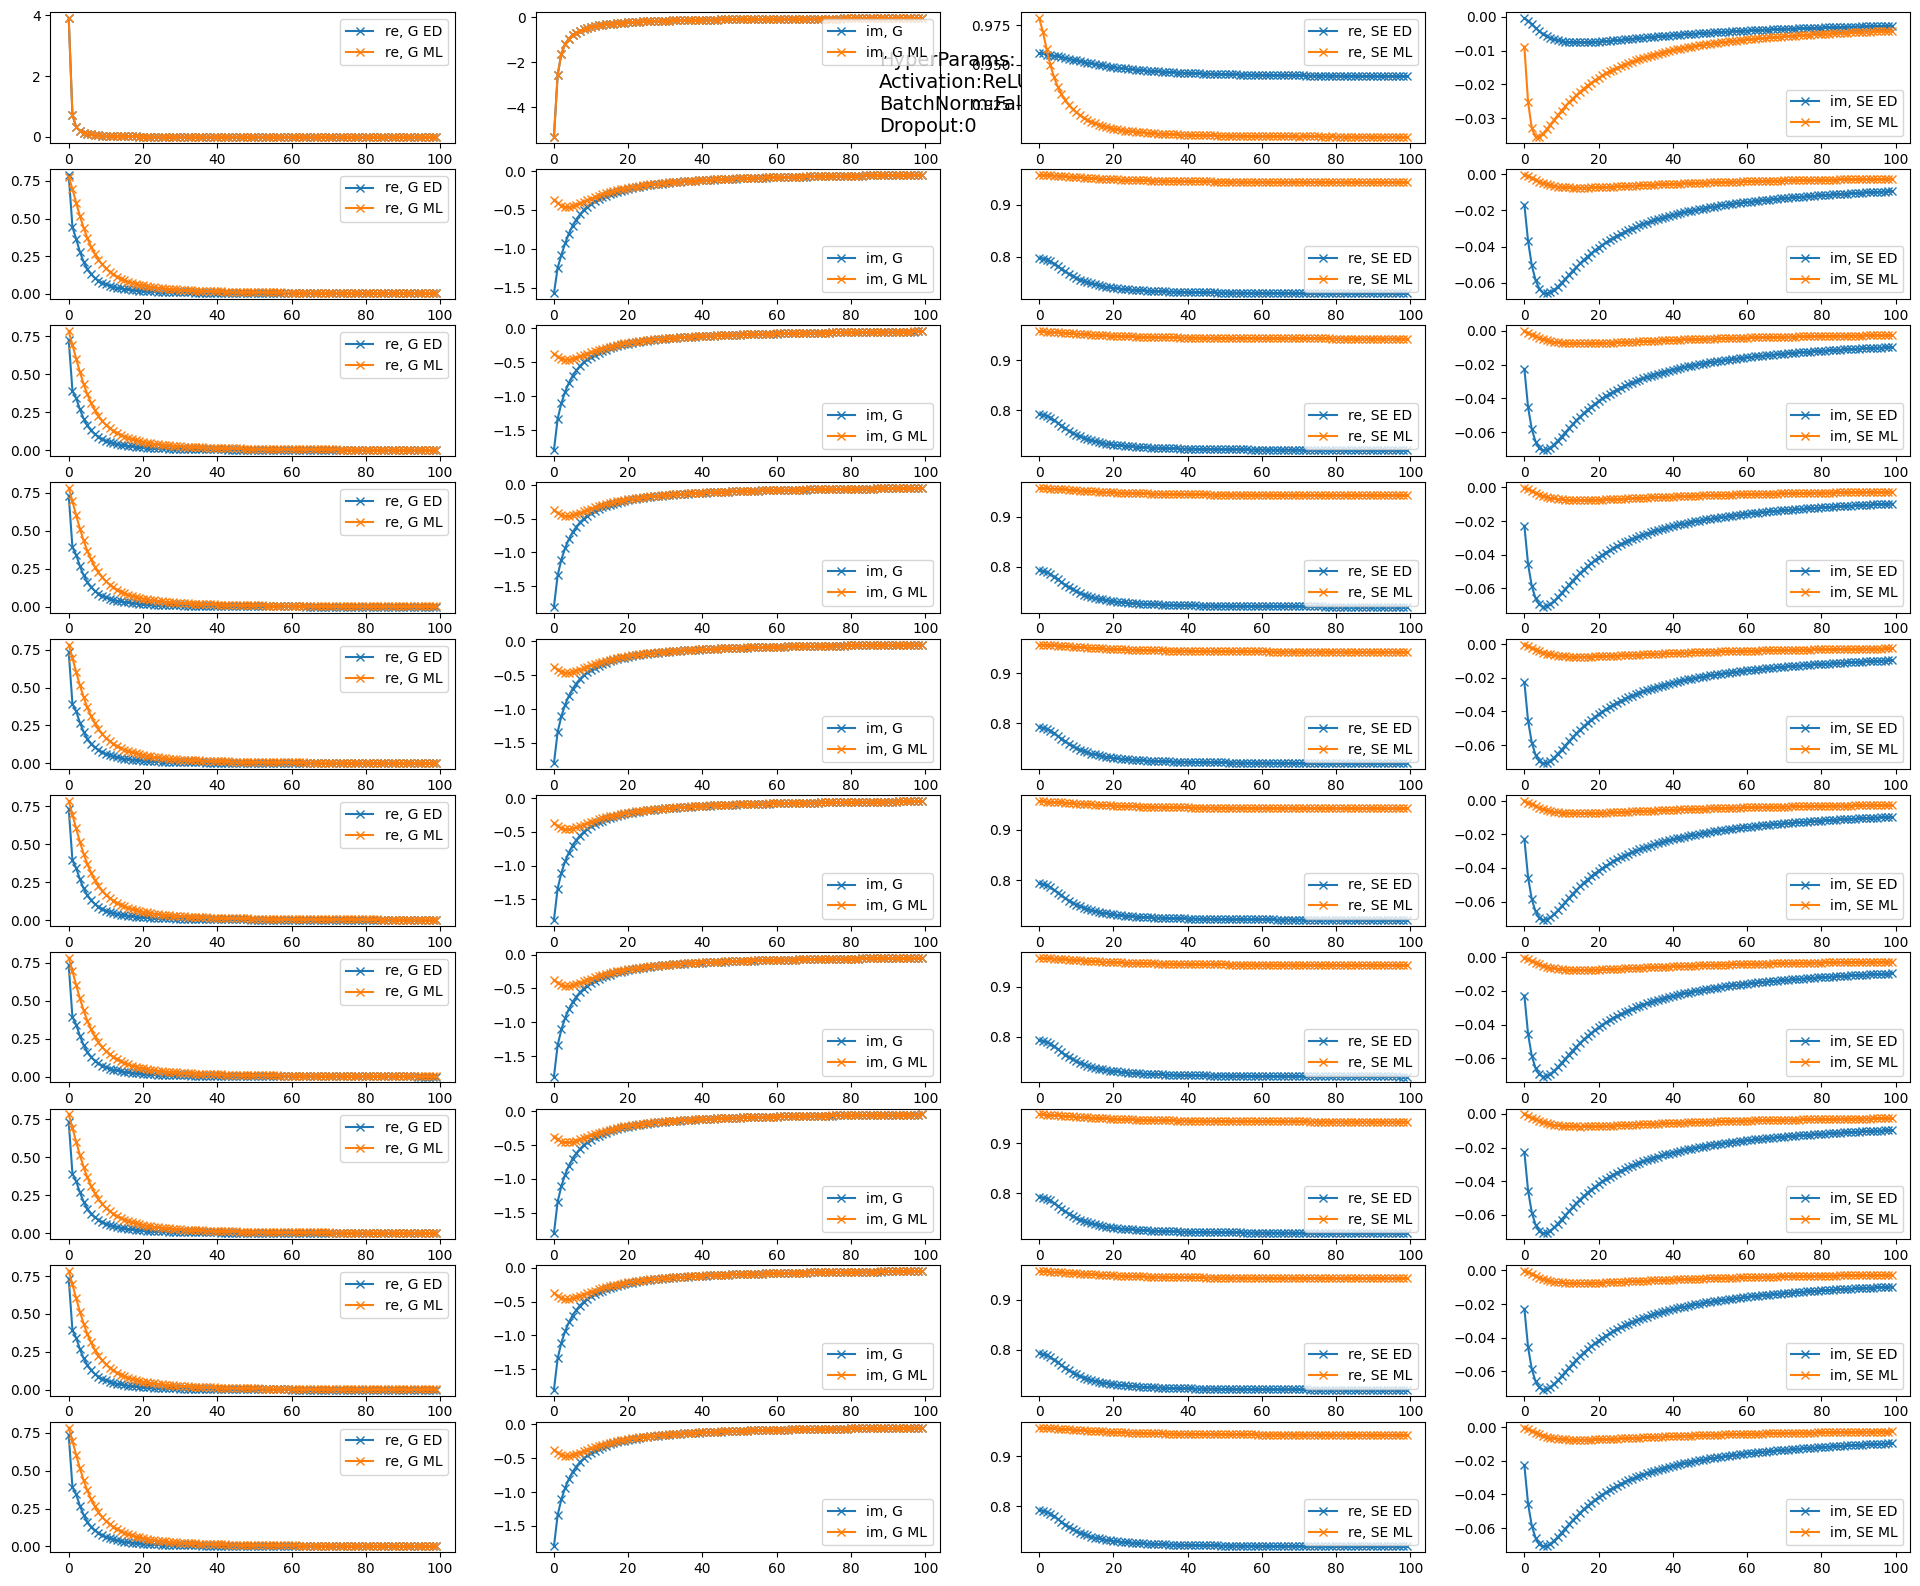

In [225]:
fig,ax = plt.subplots(len(GFImp_list),4, figsize=(24,2*len(GFImp_list)))

for i in range(len(GFImp_list)):


    if i == 0:
        text = "HyperParams:\nActivation:{}\nBatchNorm:{}\nDropout:{}".format(model.hparams["activation"],model.hparams["with_batchnorm"],model.hparams["dropout"])
        ax[i,1].text(0.85, 0.05, text, transform=ax[i,1].transAxes, fontsize=14,
        verticalalignment='bottom')
    ax[i,0].plot(jl.real(GFImp_list[i]), marker="x", label="re, G ED")
    ax[i,0].plot(jl.real(GFImp_ML_list[i]), marker="x", label="re, G ML")
    ax[i,0].legend()
    ax[i,1].plot(jl.imag(GFImp_list[i]), marker="x", label="im, G")
    ax[i,1].plot(jl.imag(GFImp_ML_list[i]), marker="x", label="im, G ML")
    ax[i,1].legend()

    ax[i,2].plot(jl.real(SEImp_list[i]), marker="x", label="re, SE ED")
    ax[i,2].plot(SEPred_it[i][0:100], marker="x", label="re, SE ML")
    ax[i,2].legend()
    ax[i,3].plot(jl.imag(SEImp_list[i]), marker="x", label="im, SE ED")
    ax[i,3].plot(SEPred_it[i][100:], marker="x", label="im, SE ML")
    ax[i,3].legend()

    #ax[i,4].plot(jl.real(SEImp_list[i]), marker="x", label="re, SE ED")
    #ax[i,4].plot(SEPred_it[i][0:100], marker="x", label="re, SE ML")
    #ax[i,4].legend()
    #ax[i,5].plot(jl.imag(SEImp_list[i]), marker="x", label="im, SE ED")
    #ax[i,5].plot(SEPred_it[i][100:], marker="x", label="im, SE ML")
    #ax[i,5].legend()

    
#fig.suptitle('No Dropout, Weighted, Medium Model Size, Medium Training Size ', fontsize=20)
plt.show()